# ScopeGuard — Risk Model (engineered + raw-scope features) - Encoding A

This notebook trains and interprets the ScopeGuard risk classifier on the
generated scope-combination dataset.

1. **Pre-process** — binarize each combination's scope list with
   `MultiLabelBinarizer` and join the engineered rubric features onto it.
2. **Split** — 70 / 15 / 15 into a training split, a validation split used
   for inspection and error analysis, and a  test split reserved for the
   final numbers.
3. **Select** — compare Random Forest, XGBoost and Logistic Regression with
   5-fold `StratifiedKFold` cross-validation on the training split, then refit
   each on the whole training split.
4. **Explain** — error analysis plus SHAP beeswarm and waterfall plots on the
   minor test split.
5. **Report** — final error analysis and assessment metrics on the super test
   split, which is touched only at the end.

Cross-validation is used the way `model_pipeline` uses it: one `StratifiedKFold`
object handed to `cross_validate` for model comparison, followed by a refit on
the full training split. No model is carried out of an individual fold.

## Configuration

Shared constants used throughout the notebook.

In [60]:
import copy
import json
import os
import random

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings("ignore")

In [61]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

SCOPE_COLUMN = "scope_urls"
TARGET_COLUMN = "risk_label"
ID_COLUMN = "combination_id"

RISK_ORDER = ["Low", "Medium", "High", "Critical"]
LABEL_TO_INDEX = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}

# Engineered rubric features joined onto the binarized scopes.
ENGINEERED_FEATURES = [
    "data_sensitivity", "persistence", "transitive_exposure", "scope_count",
    "cross_service_breadth", "has_restricted_scope", "access_level",
]

# Subset kept for the (currently unused) one-hot logistic-regression variant.
NON_ORDINAL_RISK_FEATURES = [
    "persistence", "transitive_exposure", "scope_count",
    "cross_service_breadth", "has_restricted_scope",
]
ORDINAL_RISK_FEATURES = ["data_sensitivity", "access_level"]


CV_FOLDS = 5
SCORING = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "f1": "f1_macro",
}

INPUT_PATH = "../dataset_cleaning/outputs/scope_guard_dataset_cleaned.csv"
OUTPUT_DIR = "a_outputs"

MINOR_ERROR_SAMPLES_PATH = f"{OUTPUT_DIR}/minor_test_split_error_samples.csv"
SUPER_ERROR_SAMPLES_PATH = f"{OUTPUT_DIR}/super_test_split_error_samples.csv"
CV_RESULTS_PATH = f"{OUTPUT_DIR}/cross_validation_results.csv"
SCOPE_BINARIZER_PATH = f"{OUTPUT_DIR}/scope_binarizer.joblib"
BEST_MODEL_PATH = f"{OUTPUT_DIR}/best_model.joblib"
X_TRAIN_PATH = f"{OUTPUT_DIR}/X_train.csv"

os.makedirs(OUTPUT_DIR, exist_ok=True)

## Shared helpers

Small, generic helpers used in several places below. Nothing here binarizes
anything — that is `MultiLabelBinarizer`'s job in section 1.2.

In [62]:
def split_scopes(cell):
    """Split a '; '-separated scope_urls cell into a clean list of scope URLs."""
    return [s.strip() for s in str(cell).split(";") if s.strip()]


def plot_label_distribution(labels, title, risk_order=RISK_ORDER):
    """Bar chart of label counts, ordered by risk_order.

    Accepts either string labels or the integer codes the model is trained on.
    """
    series = pd.Series(list(labels))
    if pd.api.types.is_numeric_dtype(series):
        series = series.map(lambda i: risk_order[int(i)])
    distribution = series.value_counts().reindex(risk_order).fillna(0)

    fig = plt.figure(figsize=(10, 7))
    sns.barplot(x=distribution.index, y=distribution.values, hue=distribution.index,
                palette="viridis", legend=False)
    plt.title(title, fontsize=22)
    plt.xlabel("Risk Label", fontsize=20)
    plt.ylabel("Count", fontsize=20)
    plt.xticks(fontsize=14, rotation=45, ha="right")
    plt.yticks(fontsize=14)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [63]:
def plot_assessment_metrics(model_pred_dict, y_true, labels=RISK_ORDER):
    """Plot per-class precision/recall/F1 and overall accuracy for each model.

    Inputs:
        model_pred_dict: {model name: predictions for this split}
        y_true: true labels for the split the predictions came from
        labels: class names in index order

    Output:
        one figure per model per class, plus one accuracy figure across models.
    """
    # Classification report per model, keyed by model name:
    plot_dict = {}
    accuracy_dict = {}

    for name, y_pred in model_pred_dict.items():
        new_report = classification_report(
            y_true, y_pred, output_dict=True, target_names=labels, zero_division=0
        )
        accuracy_dict[name] = new_report["accuracy"]
        plot_dict[name] = new_report

    # Per-class metrics:
    for name in plot_dict:
        for label in labels:
            report = dict(plot_dict[name][label])

            # Support is the number of instances of a class, not a quality
            # measure, so it is dropped before plotting.
            report.pop("support", None)

            plt.figure(figsize=(8, 6))
            ax = sns.barplot(x=list(report.keys()), y=list(report.values()),
                             hue=list(report.keys()), palette="viridis", legend=False)
            plt.title(f"{name} — assessment values for the {label} risk label")
            plt.ylabel("Score")
            plt.xlabel("Assessment Technique")
            plt.ylim(0.75, 1.0)
            plt.grid(axis="y", linestyle="--", alpha=0.7)

            # Printing the value inside each bar:
            for container in ax.containers:
                ax.bar_label(container, padding=3, label_type="center", color="white")

            plt.show()

    # Overall accuracy across models:
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()),
                     hue=list(accuracy_dict.keys()), palette="viridis", legend=False)
    plt.ylabel("Accuracy Across All Classes")
    plt.xlabel("Model")
    plt.title("Accuracy Across All Classes For All Models")
    for container in ax.containers:
        ax.bar_label(container, padding=3, label_type="center", color="white")
    plt.show()

In [64]:
def error_analysis(pred_dict, y_true, source_data, target_series, split_name, output_path):
    """Collect and describe the rows at least one model got wrong.

    Inputs:
        pred_dict: {model name: predictions for this split}
        y_true: true labels for the split, indexed by combination id
        source_data: the original (un-encoded) dataframe, for readable output
        target_series: encoded target for the whole dataset, indexed by id
        split_name: name used in printed output
        output_path: where the error rows are written as CSV

    Returns:
        dataframe of the error rows, with the true label and each model's
        prediction attached.
    """
    # Correctness per model, summed across models:
    correct_per_sample = sum((pd.Series(y_pred, index=y_true.index) == y_true).astype(int)
                             for y_pred in pred_dict.values())

    # Rows where at least one model missed (fewer than all models correct):
    error_mask = correct_per_sample < len(pred_dict)
    error_indices = correct_per_sample[error_mask].index

    # Pulling the readable version of those rows:
    error_samples = source_data.loc[error_indices].copy()
    error_samples["true_label"] = target_series.loc[error_indices]
    for name, y_pred in pred_dict.items():
        error_samples[f"pred_{name}"] = pd.Series(y_pred, index=y_true.index)[error_mask]

    print(f"{split_name}: {len(error_indices)} of {len(y_true)} samples had at least "
          f"one model incorrect.")
    display(error_samples)

    # Frequency of the binary risk factors among the error rows:
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(["persistence", "transitive_exposure", "has_restricted_scope"]):
        plt.subplot(1, 3, i + 1)
        sns.countplot(data=error_samples, x=col, hue=col, palette="viridis", legend=False)
        plt.title(f"Distribution of {col}\n({split_name} error samples)")
    plt.tight_layout()
    plt.show()

    error_samples.to_csv(output_path)
    print(f"Saved: {output_path}")
    return error_samples

---
## 1 — Data and pre-processing

Scopes become binary columns (one per scope URL), and the engineered rubric
features are joined on beside them.

### 1.1 — Load the dataset

Loaded 1757 rows from ../dataset_cleaning/outputs/scope_guard_dataset_cleaned.csv
risk_label
High        588
Medium      491
Critical    430
Low         248


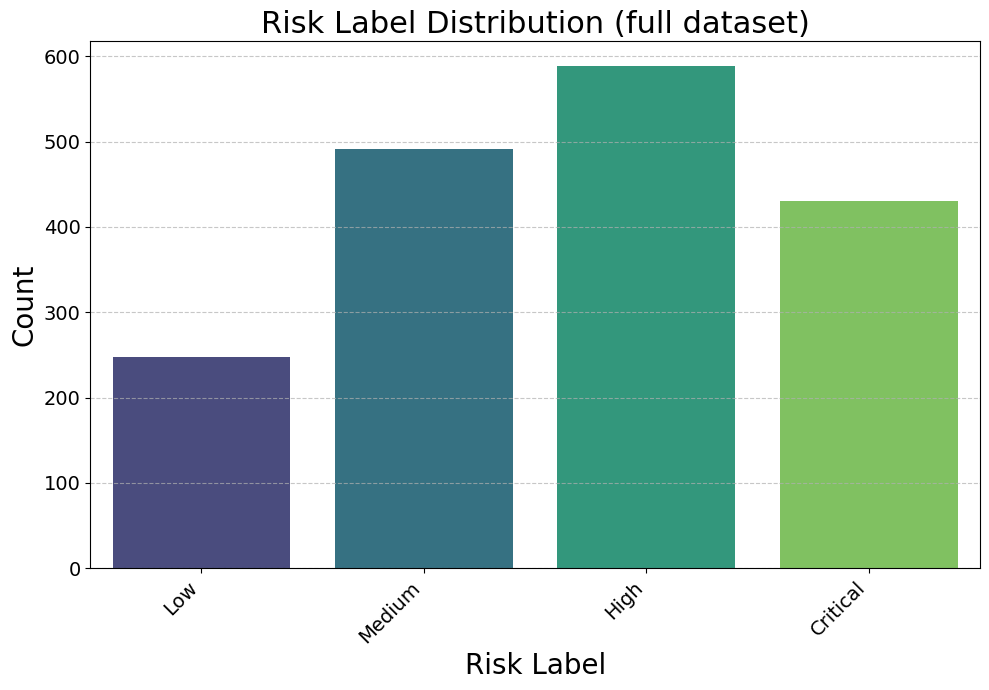

,source_category,source_label,scope_urls,data_sensitivity,persistence,transitive_exposure,scope_count,cross_service_breadth,has_restricted_scope,access_level,risk_label
combination_id,,,,,,,,,,,
SC-0000,Student Created,Offline access to actively monitor fitness act...,openid; profile; email; https://www.googleapis...,4,1,0,6,3,0,2,Critical
SC-0001,Student Created,"Full online access to YouTube account, includi...",openid; profile; email; https://www.googleapis...,4,0,0,5,3,0,2,High
SC-0002,Student Created,"Authentication, email adress, personalization ...",openid; profile; email; https://www.googleapis...,5,0,1,5,3,0,1,High
SC-0003,Student Created,"Authentication, email adress, personalization ...",openid; profile; email; https://www.googleapis...,4,1,0,5,3,0,1,High
SC-0004,Student Created,"Authentication, email adress, personalization ...",openid; profile; email; https://www.googleapis...,4,0,0,4,2,0,2,High


In [65]:
data = pd.read_csv(INPUT_PATH)

# Indexing by combination id keeps SC-XXXX traceable through every split, which
# is what makes the error analysis in sections 5 and 8 readable.
data.index = data[ID_COLUMN]
data = data.drop(columns=[ID_COLUMN])

print(f"Loaded {len(data)} rows from {INPUT_PATH}")
print(data[TARGET_COLUMN].value_counts().to_string())

plot_label_distribution(data[TARGET_COLUMN], "Risk Label Distribution (full dataset)")
data.head()

### 1.2 — Binarize the scope lists

One binary column per scope URL. This widens the feature matrix considerably,
but it is what lets the model reason about the scopes themselves rather than
about the rubric alone.

In [66]:
scope_lists = data[SCOPE_COLUMN].apply(split_scopes)

scope_binarizer = MultiLabelBinarizer()
one_hot_scopes = scope_binarizer.fit_transform(scope_lists)

print(f"Scope vocabulary: {len(scope_binarizer.classes_)} distinct scopes")
print(f"First combination: {scope_lists.iloc[0]}")
print(f"Encoded as:        {one_hot_scopes[0]}")

# Column names must follow the binarizer's own class order, and the index is
# aligned back onto the combination ids.
preprocessed_data = pd.DataFrame(one_hot_scopes, columns=scope_binarizer.classes_,
                                 index=data.index)
preprocessed_data.head()
for a in preprocessed_data.columns:
    print(a)

Scope vocabulary: 131 distinct scopes
First combination: ['openid', 'profile', 'email', 'https://www.googleapis.com/auth/fitness.activity.read', 'https://www.googleapis.com/auth/fitness.body.read', 'https://www.googleapis.com/auth/spreadsheets']
Encoded as:        [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]
email
https://mail.google.com/
https://www.googleapis.com/auth/admin.datatransfer
https://www.googleapis.com/auth/admin.directory.domain
https://www.googleapis.com/auth/admin.directory.group
https://www.googleapis.com/auth/admin.directory.rolemanagement
https://www.googleapis.com/auth/admin.directory.user
https://www.googleapis.com/auth/admin.directory.user.readonly
https://www.googleapis.com/auth/admin.directory.user.security
https://www.googleapis.com/auth/admin

### 1.3 — Join the engineered risk features

The rubric features are added alongside the scope columns, so the model sees
both the raw request and the derived risk signals.

In [67]:
preprocessed_data[ENGINEERED_FEATURES] = data[ENGINEERED_FEATURES]
preprocessed_data[TARGET_COLUMN] = data[TARGET_COLUMN]

print(f"Feature matrix: {preprocessed_data.shape[0]} rows x "
      f"{preprocessed_data.shape[1] - 1} columns "
      f"({len(scope_binarizer.classes_)} scope + {len(ENGINEERED_FEATURES)} engineered)")
preprocessed_data[ENGINEERED_FEATURES]

Feature matrix: 1757 rows x 138 columns (131 scope + 7 engineered)


,data_sensitivity,persistence,transitive_exposure,scope_count,cross_service_breadth,has_restricted_scope,access_level
combination_id,,,,,,,
SC-0000,4,1,0,6,3,0,2
SC-0001,4,0,0,5,3,0,2
SC-0002,5,0,1,5,3,0,1
SC-0003,4,1,0,5,3,0,1
SC-0004,4,0,0,4,2,0,2
...,...,...,...,...,...,...,...
SC-1889,3,0,0,2,1,0,1
SC-1890,3,0,0,3,1,0,1
SC-1891,3,0,0,2,1,0,1


### 1.3b — One-hot ordinal variant (kept for reference, not used)

One-hot encoding the ordinal features gave a slight *decrease* in logistic
regression performance, so the model below uses the ordinal columns as they
are. The variant is kept here for future reference.

In [68]:
lr_preprocessed_data = copy.deepcopy(preprocessed_data.drop(columns=[TARGET_COLUMN]))
ordinal_data = copy.deepcopy(data[ORDINAL_RISK_FEATURES])

# get_dummies keeps the result readable: one column per level, named after it.
ordinal_data = pd.get_dummies(ordinal_data, columns=ORDINAL_RISK_FEATURES,
                              prefix=ORDINAL_RISK_FEATURES)
ordinal_data = ordinal_data.astype(int)

lr_preprocessed_data[ordinal_data.columns] = ordinal_data
lr_preprocessed_data[NON_ORDINAL_RISK_FEATURES] = data[NON_ORDINAL_RISK_FEATURES]

print(f"Reference variant: {lr_preprocessed_data.shape[1]} columns "
      f"(target held separately in `target`)")

Reference variant: 147 columns (target held separately in `target`)


### 1.4 — Separate and encode the target

The target is pulled out of the feature matrix so no model can see the answer,
and mapped onto ordered integer codes (Low=0 ... Critical=3).

In [69]:
target = preprocessed_data[TARGET_COLUMN].map(LABEL_TO_INDEX)
preprocessed_data = preprocessed_data.drop(columns=[TARGET_COLUMN])

feature_names = preprocessed_data.columns.tolist()

print(f"Target encoded as {LABEL_TO_INDEX}")
print(target.value_counts().sort_index().to_string())
print(type(preprocessed_data))

Target encoded as {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
risk_label
0    248
1    491
2    588
3    430
<class 'pandas.core.frame.DataFrame'>


---
## 2 — Train / test splits

| Split | Size | Purpose |
|---|---|---|
| `Train` | 70% | Model fitting; the 5-fold CV in section 3 runs here |
| `Validate` | 15% | Inspection, error analysis and SHAP — safe to look at freely |
| `Test` | 15% | Touched **once**, at the end. No decisions are made from it |

Splitting first means model selection can never see the test rows, so the final
numbers are not optimistic. Both splits are stratified to keep the class
proportions representative.

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    preprocessed_data,
    target,
    test_size=.3,
    shuffle=True,
    random_state=RANDOM_SEED,
    stratify=target,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test,
    y_test,
    test_size=.5,
    shuffle=True,
    random_state=RANDOM_SEED,
    stratify=y_test,
)

---
## 3 — Cross-validated model comparison

Every candidate is scored with the **same** `StratifiedKFold` object, so all
three see identical folds and the comparison is like-for-like. `cross_validate`
returns one score per fold per metric; the fold-level numbers are printed for
inspection, and the fold *mean* is what selects the model.

No fitted estimator is taken out of a fold. A single fold's model is fit on 80%
of the training split and scored on rows that happen to suit it, so picking the
best-scoring fold selects for fold noise rather than for the better model. The
selected estimator is refit on the whole training split in section 4 instead.

In [71]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

candidate_models = {
    "RandomForest": RandomForestClassifier(random_state=RANDOM_SEED),
    "XGBoost": XGBClassifier(random_state=RANDOM_SEED),
    "LogisticRegression": LogisticRegression(random_state=RANDOM_SEED, max_iter=1000000),
}

cv_results = {}
for name, candidate in candidate_models.items():
    scores = cross_validate(candidate, X_train, y_train,
                            cv=cv, scoring=SCORING)
    cv_results[name] = {metric: scores[f"test_{metric}"] for metric in SCORING}

    print(f"\n{name}")
    for fold in range(CV_FOLDS):
        fold_scores = "  ".join(f"{m}={cv_results[name][m][fold]:.4f}" for m in SCORING)
        print(f"  Fold {fold}: {fold_scores}")
    means = "  ".join(f"{m}={cv_results[name][m].mean():.4f}" for m in SCORING)
    print(f"  MEAN:   {means}")


RandomForest
  Fold 0: accuracy=0.9228  precision=0.9262  recall=0.9228  f1=0.9346
  Fold 1: accuracy=0.8943  precision=0.8977  recall=0.8943  f1=0.9081
  Fold 2: accuracy=0.9268  precision=0.9295  recall=0.9268  f1=0.9345
  Fold 3: accuracy=0.9228  precision=0.9224  recall=0.9228  f1=0.9320
  Fold 4: accuracy=0.9265  precision=0.9279  recall=0.9265  f1=0.9334
  MEAN:   accuracy=0.9186  precision=0.9207  recall=0.9186  f1=0.9285

XGBoost
  Fold 0: accuracy=0.9715  precision=0.9723  recall=0.9715  f1=0.9765
  Fold 1: accuracy=0.9431  precision=0.9427  recall=0.9431  f1=0.9525
  Fold 2: accuracy=0.9634  precision=0.9655  recall=0.9634  f1=0.9643
  Fold 3: accuracy=0.9634  precision=0.9637  recall=0.9634  f1=0.9670
  Fold 4: accuracy=0.9796  precision=0.9802  recall=0.9796  f1=0.9827
  MEAN:   accuracy=0.9642  precision=0.9649  recall=0.9642  f1=0.9686

LogisticRegression
  Fold 0: accuracy=0.9309  precision=0.9320  recall=0.9309  f1=0.9393
  Fold 1: accuracy=0.8984  precision=0.8986  re

In [72]:
cv_summary = pd.DataFrame({
    name: {f"{metric}_mean": scores[metric].mean() for metric in SCORING}
          | {f"{metric}_std": scores[metric].std() for metric in SCORING}
    for name, scores in cv_results.items()
}).T[[f"{m}_{s}" for m in SCORING for s in ("mean", "std")]]

display(cv_summary.round(4))
cv_summary.to_csv(CV_RESULTS_PATH)
print(f"Saved: {CV_RESULTS_PATH}")

# Ranking on mean macro-F1: it weights every risk class equally, which matters
# because Low is the smallest class and the one a user most needs distinguished.
ranking = sorted(cv_results, key=lambda n: cv_results[n]["f1"].mean(), reverse=True)
best_name, second_best_name = ranking[0], ranking[1]

print(f"\nSELECTED MODEL:  {best_name} "
      f"(CV macro-F1 = {cv_results[best_name]['f1'].mean():.4f} "
      f"+/- {cv_results[best_name]['f1'].std():.4f})")
print(f"SECOND MODEL:    {second_best_name} "
      f"(CV macro-F1 = {cv_results[second_best_name]['f1'].mean():.4f} "
      f"+/- {cv_results[second_best_name]['f1'].std():.4f})")

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
RandomForest,0.9186,0.0123,0.9207,0.0117,0.9186,0.0123,0.9285,0.0103
XGBoost,0.9642,0.0121,0.9649,0.0125,0.9642,0.0121,0.9686,0.0104
LogisticRegression,0.9154,0.0122,0.9163,0.0126,0.9154,0.0122,0.9202,0.0130


Saved: a_outputs/cross_validation_results.csv

SELECTED MODEL:  XGBoost (CV macro-F1 = 0.9686 +/- 0.0104)
SECOND MODEL:    RandomForest (CV macro-F1 = 0.9285 +/- 0.0103)


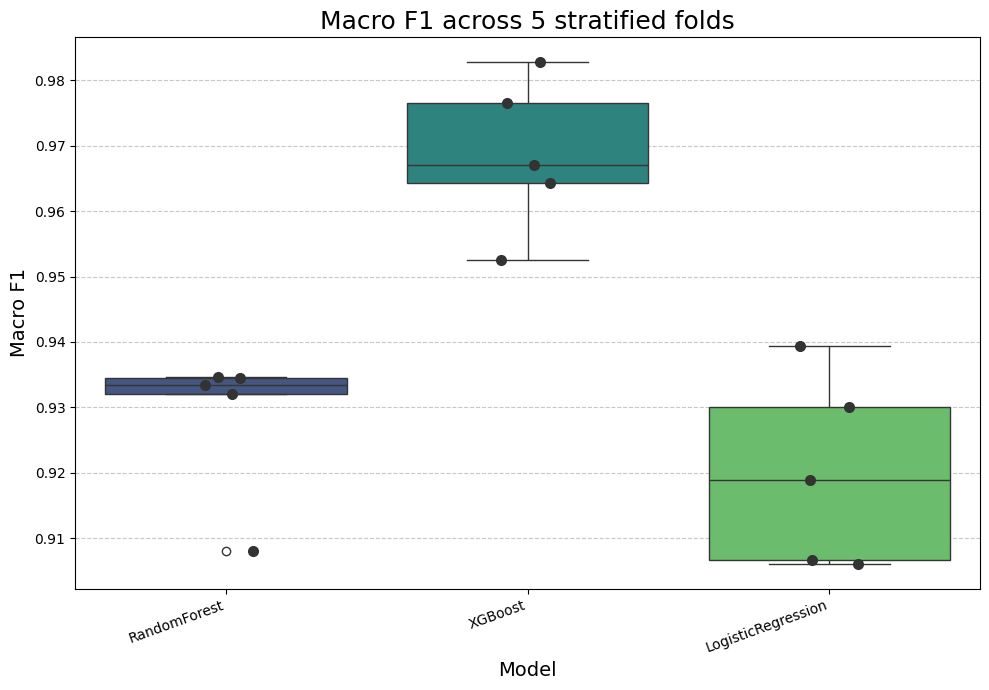

In [73]:
# Fold-level spread per model. A wide box means the model's score depends on
# which rows it happened to train on, which is exactly what a single-fold
# selection would have latched onto.
f1_long = pd.DataFrame({name: scores["f1"] for name, scores in cv_results.items()}).melt(
    var_name="Model", value_name="Macro F1")

fig = plt.figure(figsize=(10, 7))
sns.boxplot(data=f1_long, x="Model", y="Macro F1", hue="Model",
            palette="viridis", legend=False)
sns.stripplot(data=f1_long, x="Model", y="Macro F1", color="0.2", size=8)
plt.title(f"Macro F1 across {CV_FOLDS} stratified folds", fontsize=18)
plt.xlabel("Model", fontsize=14)
plt.ylabel("Macro F1", fontsize=14)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
plt.close(fig)

---
## 4 — Refit on the full training split

Cross-validation has done its job (choosing between model types), so each
candidate is now refit on the entire training split. These fitted estimators
are what the rest of the notebook evaluates and explains.

In [74]:
fitted_models = {}
for name, candidate in candidate_models.items():
    model = copy.deepcopy(candidate)
    model.fit(super_X_train, super_y_train)
    fitted_models[name] = model
    print(f"Fitted {name} on {len(super_X_train)} training rows")

# Convenience aliases used by the error analysis and SHAP sections.
rf_model = fitted_models["RandomForest"]
xgb_model = fitted_models["XGBoost"]
lr_model = fitted_models["LogisticRegression"]

best_model = fitted_models[best_name]
second_best_model = fitted_models[second_best_name]

NameError: name 'super_X_train' is not defined

---
## 5 — Minor test split: error analysis

Which combinations the models disagree with the rubric on, and what those
combinations have in common. This split is for inspection, so it can be looked
at as often as needed.

In [ ]:
minor_preds_dict = {name: model.predict(minor_X_test)
                    for name, model in fitted_models.items()}

minor_error_samples = error_analysis(
    minor_preds_dict, minor_y_test, data, target,
    split_name="Minor test", output_path=MINOR_ERROR_SAMPLES_PATH,
)

### 5.1 — Assessment metrics on the minor test split

In [ ]:
plot_assessment_metrics(minor_preds_dict, minor_y_test)

for name, y_pred in minor_preds_dict.items():
    print(f"\n{name}")
    print(f"Accuracy: {accuracy_score(minor_y_test, y_pred):.4f}")
    print(f"Macro-F1: {f1_score(minor_y_test, y_pred, average='macro'):.4f}\n")
    print(classification_report(minor_y_test, y_pred, target_names=RISK_ORDER,
                                zero_division=0))

---
## 6 — SHAP explanations on the minor test split

One explainer per model. The linear explainer needs a background distribution;
it is given the whole training split rather than SHAP's default subsample, so
the baseline reflects all of the data the model actually saw.

In [ ]:
# The masker's max_samples is set to the size of the background set so SHAP
# uses all of it instead of its default subsample.
background_data = super_X_train
masker = shap.maskers.Independent(background_data, max_samples=len(background_data))

logreg_explainer = shap.LinearExplainer(lr_model, masker)
minor_logreg_shap_values = logreg_explainer(minor_X_test)

rf_explainer = shap.TreeExplainer(rf_model)
minor_rf_shap_values = rf_explainer(minor_X_test)

xgb_explainer = shap.TreeExplainer(xgb_model)
minor_xgb_shap_values = xgb_explainer(minor_X_test)

shap_values_by_model = {
    "RandomForest": minor_rf_shap_values,
    "XGBoost": minor_xgb_shap_values,
    "LogisticRegression": minor_logreg_shap_values,
}
print("SHAP values computed for", ", ".join(shap_values_by_model))

### 6.1 — Beeswarm plots

Global view: which features move each class, across the whole minor test
split.

In [ ]:
for name, shap_values in shap_values_by_model.items():
    print(f"\n\n{name}")

    # One plot per class: SHAP returns a value per feature per class, so the
    # class axis has to be sliced out before plotting.
    for class_index, class_name in enumerate(RISK_ORDER):
        explanation_sample = shap.Explanation(
            values=shap_values.values[:,             # every sample in the split
                                      :,             # every feature
                                      class_index],  # the class being displayed
            base_values=shap_values.base_values[:, class_index],
            data=minor_X_test,
            feature_names=feature_names,
        )
        print(f"{name} — {class_name} class")
        shap.plots.beeswarm(explanation_sample, max_display=25)

### 6.2 — Waterfall plots for a single combination

Local view: how one specific request was pushed toward each class.

In [ ]:
# Set COMBO_ID to a combination id present in the minor test split to explain
# that row instead of the first one.
COMBO_ID = None
sample_index = 0 if COMBO_ID is None else minor_X_test.index.get_loc(COMBO_ID)

print(f"Explaining {minor_X_test.index[sample_index]}")
display(data.loc[minor_X_test.index[sample_index]])

for name, shap_values in shap_values_by_model.items():
    print(f"\n\n{name}")

    for class_index, class_name in enumerate(RISK_ORDER):
        explanation_sample = shap.Explanation(
            values=shap_values.values[sample_index,   # the one sample
                                      :,              # every feature
                                      class_index],   # the class being displayed
            base_values=shap_values.base_values[sample_index, class_index],
            data=minor_X_test.iloc[sample_index],
            feature_names=feature_names,
        )
        print(f"{name} — {class_name} class")
        shap.plots.waterfall(explanation_sample)

### 6.3 — Anchor explanations

Not implemented yet: Anchor is computationally expensive and will likely need
to run off-notebook.

---
## 7 — Super test split: error analysis

The final held-out split. Nothing below this point feeds back into model
selection or tuning.

In [ ]:
super_preds_dict = {name: model.predict(super_X_test)
                    for name, model in fitted_models.items()}

super_error_samples = error_analysis(
    super_preds_dict, super_y_test, data, target,
    split_name="Super test", output_path=SUPER_ERROR_SAMPLES_PATH,
)

### 7.1 — Assessment metrics on the super test split

These are the numbers to report.

In [ ]:
plot_assessment_metrics(super_preds_dict, super_y_test)

for name, y_pred in super_preds_dict.items():
    print(f"\n{name}")
    print(f"Accuracy:  {accuracy_score(super_y_test, y_pred):.4f}")
    print(f"Macro-F1:  {f1_score(super_y_test, y_pred, average='macro'):.4f}")
    print(f"Precision: {precision_score(super_y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Recall:    {recall_score(super_y_test, y_pred, average='weighted', zero_division=0):.4f}\n")
    print(classification_report(super_y_test, y_pred, target_names=RISK_ORDER,
                                zero_division=0))

### 7.2 — Confusion matrix for the selected model

In [ ]:
cm = confusion_matrix(super_y_test, super_preds_dict[best_name],
                      labels=np.arange(len(RISK_ORDER)))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=RISK_ORDER, yticklabels=RISK_ORDER, ax=ax)
ax.set_title(f"Confusion Matrix — {best_name} (Super Test Split)", fontsize=18)
ax.set_xlabel("Predicted Label", fontsize=14)
ax.set_ylabel("True Label", fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

plot_label_distribution(super_y_test, "True Risk Labels in the Super Test Split")

---
## 8 — Save the model and supporting artifacts

In [ ]:
joblib.dump(best_model, BEST_MODEL_PATH)
print(f"Selected model ({best_name}) saved to {BEST_MODEL_PATH}")

joblib.dump(scope_binarizer, SCOPE_BINARIZER_PATH)
print(f"Scope binarizer saved to {SCOPE_BINARIZER_PATH}")

super_X_train.to_csv(X_TRAIN_PATH, index=True)
print(f"Training split saved to {X_TRAIN_PATH}")